In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [36]:
orders = pd.read_csv(r"..\Blinkit_datasets\blinkit_orders.csv")
customer = pd.read_csv(r"..\Blinkit_datasets\blinkit_customers.csv")

In [37]:
customer.columns

Index(['customer_id', 'customer_name', 'email', 'phone', 'address', 'area',
       'pincode', 'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value'],
      dtype='object')

In [38]:
customer['registration_date'] = pd.to_datetime(customer['registration_date'])
customer['reg_year_month'] = customer['registration_date'].dt.to_period('M').dt.to_timestamp()
customer['estimated_revenue'] = customer['total_orders'] * customer['avg_order_value']

# Customer analysis 

# ----------------------------------------------------------------------------------------

In [39]:
customers = customer['customer_id'].nunique()
print("Total Users: ", customers)

Total Users:  2500


- The business has 2500 unique registered customers.

# Customer registration trend

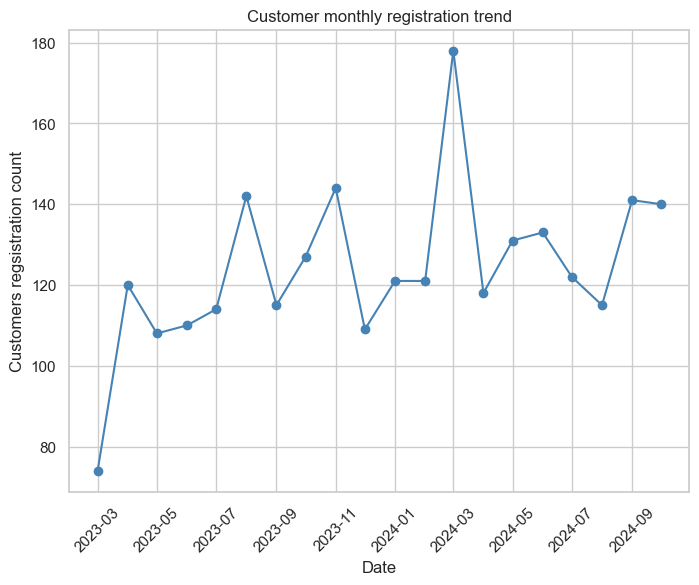

In [40]:
customer_count = (customer.groupby(['reg_year_month'], as_index = False)['customer_id'].count())
customer_count = customer_count[~(customer_count['reg_year_month'] == '2024-11-01 00:00:00')]

fig, ax = plt.subplots(figsize=(8,6))

plt.plot(customer_count['reg_year_month'], customer_count['customer_id'], marker = 'o', color='steelblue')

plt.title('Customer monthly registration trend')
plt.xlabel('Date')                  
plt.ylabel('Customers regsistration count')  
plt.xticks(rotation=45)
plt.show()

- Customer registrations remain relatively stable over time, with a noticeable peak around February 2024
- The consistent registration trend indicates steady customer acquisition throughout the observed period

# Estimated Customer Revenue by Segment

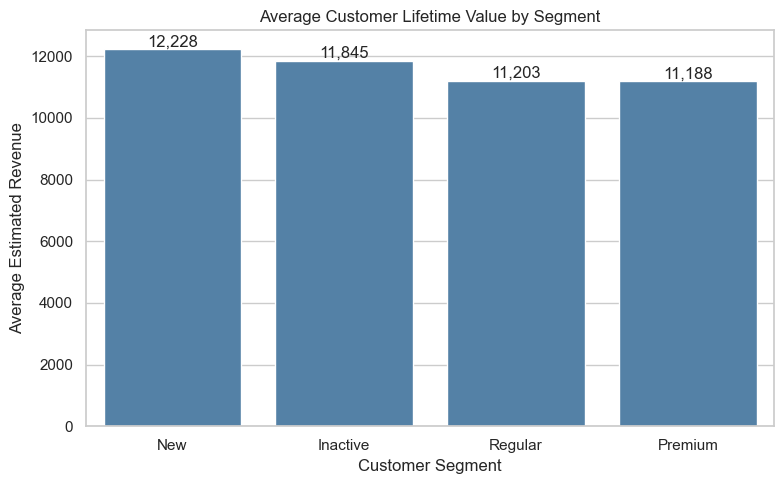

In [41]:
segment_clv = customer.groupby('customer_segment', as_index=False)['estimated_revenue'].mean().sort_values(by='estimated_revenue',ascending=False)


plt.figure(figsize=(8,5))

ax=sns.barplot(data=segment_clv, x='customer_segment',y='estimated_revenue', color='steelblue')

plt.title('Average Customer Lifetime Value by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Estimated Revenue')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
    
plt.tight_layout()
plt.show()

- New customers have the highest average estimated lifetime value, while the differences across segments remain relatively small
- This suggests newly acquired customers are currently generating strong revenue and should be retained through continued engagement

# Distribution of orders per customer

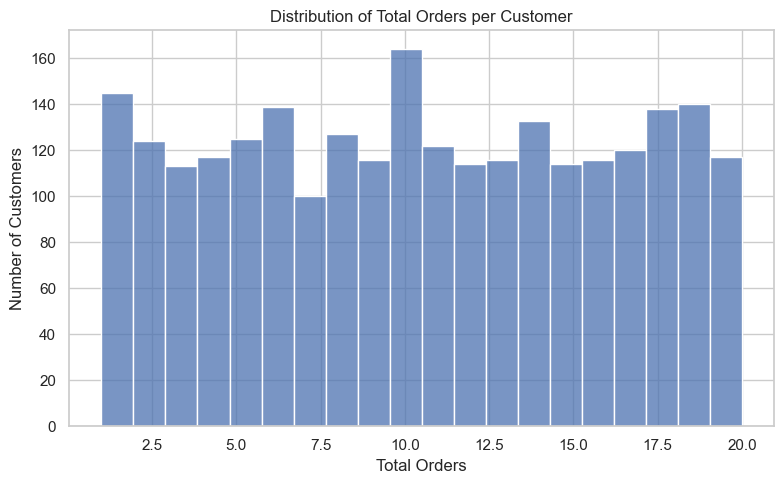

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(customer['total_orders'],bins=20,kde=False)

plt.title('Distribution of Total Orders per Customer')
plt.xlabel('Total Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

- Customers exhibit a broad range of purchase frequencies, indicating diverse buying behavior
- The balanced distribution suggests the business is not overly dependent on customers with a single purchase frequency

# Average order value distribution

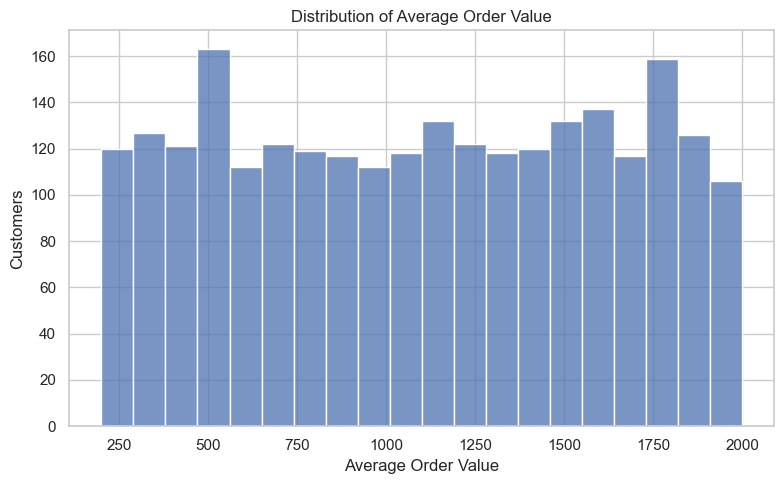

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(customer['avg_order_value'],bins=20,kde=False)

plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Customers')

plt.tight_layout()
plt.show()

- Average order values are well distributed across customers without extreme outliers
- Increasing basket size through cross-selling and bundled offers could further improve revenue.

# Repeat purchase rate

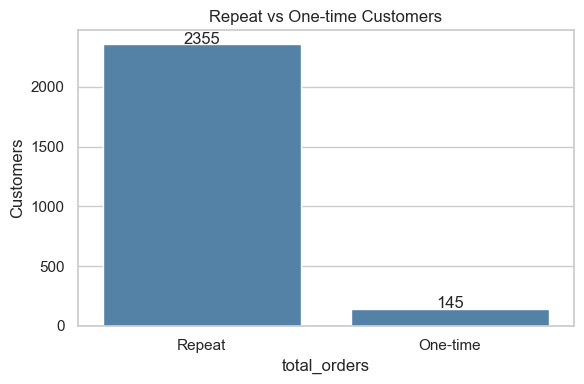

In [44]:
repeat = (customer['total_orders'] > 1).map({True:'Repeat',False:'One-time'}).value_counts()

plt.figure(figsize=(6,4))

sns.barplot(x=repeat.index,y=repeat.values,color='steelblue')

plt.title('Repeat vs One-time Customers')
plt.ylabel('Customers')

for i,v in enumerate(repeat.values):
    plt.text(i,v+5,str(v),ha='center')

plt.tight_layout()
plt.show()

- Approximately 94% of customers are repeat buyers, indicating strong customer retention
- The low proportion of one-time customers suggests customers are likely to return after their first purchase

# Top 10 customers by estimated revenue

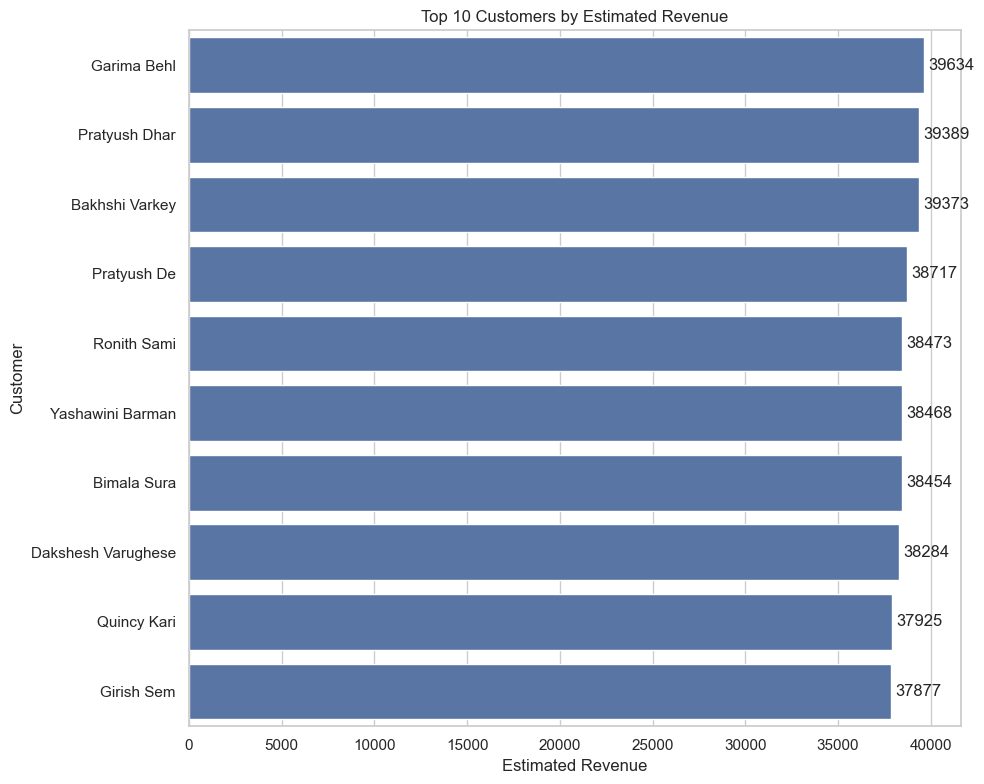

In [45]:
top_customer = customer.sort_values('estimated_revenue',ascending=False).head(10)


plt.figure(figsize=(10, 8))

ax = sns.barplot(data=top_customer,x='estimated_revenue',y='customer_name',legend=False)

ax.bar_label(ax.containers[0],fmt='%.0f', padding=3)

plt.title('Top 10 Customers by Estimated Revenue')
plt.xlabel('Estimated Revenue')
plt.ylabel('Customer')

plt.tight_layout()
plt.show()

- A small group of customers contributes the highest individual revenue
- Retaining these high-value customers through personalized offers can support long-term revenue growth

# Segment wise customer share

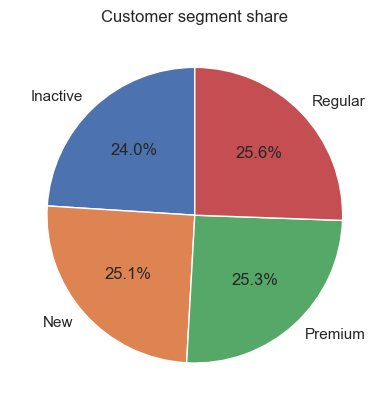

In [46]:
customer.groupby('customer_segment')['customer_id'].count().plot(kind='pie', autopct='%1.1f%%', startangle = 90)

plt.title('Customer segment share')
plt.ylabel('')

plt.show()

- Customer segments are almost evenly distributed across the customer base
- No single segment dominates, indicating a balanced customer portfolio

# Segment wise customer analysis

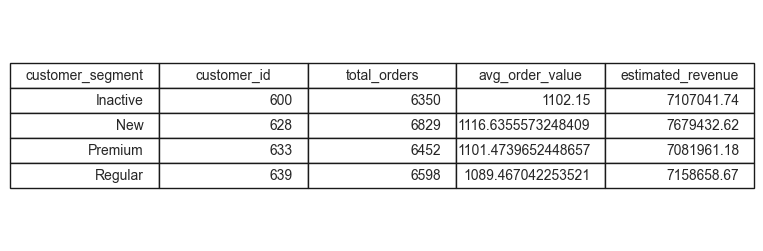

In [47]:
customer['estimated_revenue'] = customer['total_orders'] * customer['avg_order_value']
Segment_wise_KPI = customer.groupby('customer_segment', as_index  =False).agg({'customer_id':'count', 'total_orders':'sum', 'avg_order_value':'mean', 'estimated_revenue':'sum'})
Segment_wise_KPI.sort_values(by = 'estimated_revenue', ascending = False)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(cellText=Segment_wise_KPI.values,colLabels=Segment_wise_KPI.columns,loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.show()

- Regular customers contribute the highest total revenue, while Premium customers place the highest number of orders
- New customers have the highest average order value, suggesting strong spending among recently acquired customers

# Customer Recency Distribution 

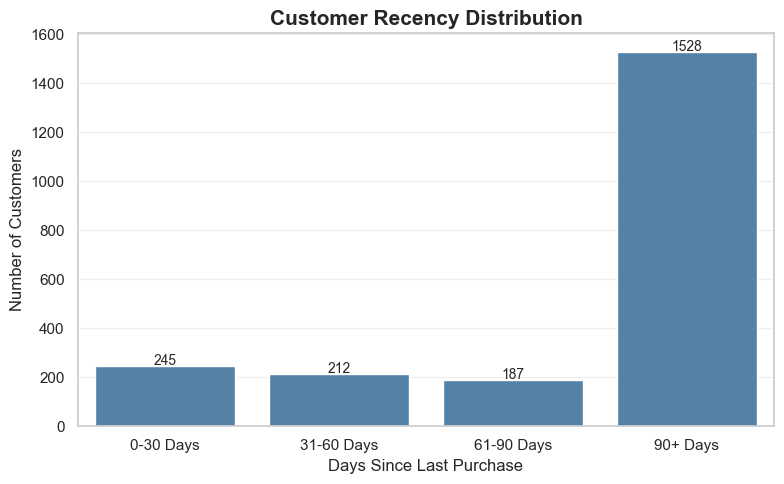

In [48]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
customer_max_order_date = orders.groupby('customer_id')['order_date'].max()
customer['last_order_date'] = customer['customer_id'].map(customer_max_order_date)
customer['last_order_date'] = pd.to_datetime(customer['last_order_date'])

reference_date = orders['order_date'].max()

customer['days_since_last_purchase'] = (reference_date - customer['last_order_date']).dt.days

bins = [0, 30, 60, 90, customer['days_since_last_purchase'].max() + 1]

labels = ['0-30 Days','31-60 Days','61-90 Days','90+ Days']

customer['recency_bucket'] = pd.cut(customer['days_since_last_purchase'],bins=bins,labels=labels,include_lowest=True)

recency = customer['recency_bucket'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(x=recency.index,y=recency.values,color='steelblue')

for i, v in enumerate(recency.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=10)

plt.title('Customer Recency Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- A considerable proportion of customers fall into the 90+ day recency bucket, indicating a meaningful inactive customer segment that could be targeted through re-engagement campaigns

# Top cities by customer count

In [49]:
customer_city = customer.groupby('area', as_index=False)['customer_id'].count()
customer_city.columns=['City', 'Count of customers']
customer_city.sort_values(by='Count of customers', ascending = False).head(20).style.hide(axis='index')


City,Count of customers
Jalna,18
Deoghar,17
Bathinda,17
Orai,17
Ratlam,16
Ghaziabad,16
Kishanganj,15
Kadapa,14
Kalyan-Dombivli,14
Gandhinagar,14


# Final business insights

- The business maintains a stable customer acquisition trend with a total customer base of 2,500 customers
- Customer retention is a major strength, with 94% of customers making repeat purchases
- Customer segments are evenly distributed, but purchasing behavior differs across segments, with Regular customers generating the highest total revenue and New customers showing the highest average customer lifetime value
- A significant number of customers have not purchased in over 90 days, highlighting an opportunity for targeted re-engagement campaigns
- Future growth should focus on retaining high-value customers, reactivating inactive customers, and increasing average order value through personalized marketing strategies